## Árboles de Decisión en Machine Learning
###### Elizabeth Vega Pacheco
###### Ariana Belinda Pulido Solano
###### Juan Gerardo Reyes Carrera
###### Hugo Martínez Vallejo

### 1. Carga de librerías.
Aquí incorporaremos las librerías necesarias.

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np

# Dataset de ejemplo y utilidades de sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Métricas de evaluación
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Visualización
import matplotlib.pyplot as plt

%matplotlib inline

### 2. Carga del dataset
Usaremos el dataset del Iris, este dataset es muy usado en la comunidad de machine learning...

In [2]:
iris = load_iris()

# Convertimos a DataFrame para visualizarlo mejor
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['especie'] = iris.target
df['especie'] = df['especie'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Distribución de clases
df['especie'].value_counts()

especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### 3. Preprocesamiento

Pasos básicos antes de entrenar:
- Verificar valores nulos
- Separar variables predictoras (X) y variable objetivo (y)
- Dividir en conjunto de entrenamiento y prueba

In [4]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum()) #Datos nulos = true:1 #Datos reales = false:0

Valores nulos por columna:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
especie              0
dtype: int64


In [5]:
# Variables predictoras (X) y variable objetivo (y)
X = df[iris.feature_names]
y = df['especie']

# División train/test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (120, 4)
Prueba: (30, 4)


### 4. Entrenamiento del algoritmo

Creamos y entrenamos un DecisionTreeClassifier. Limitamos la profundidad máxima (max_depth)
para evitar sobreajuste y facilitar la visualización del árbol.


In [6]:
modelo = DecisionTreeClassifier(
    criterion='gini',   # criterio de división
    max_depth=3,         # profundidad máxima del árbol
    random_state=42
)

modelo.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


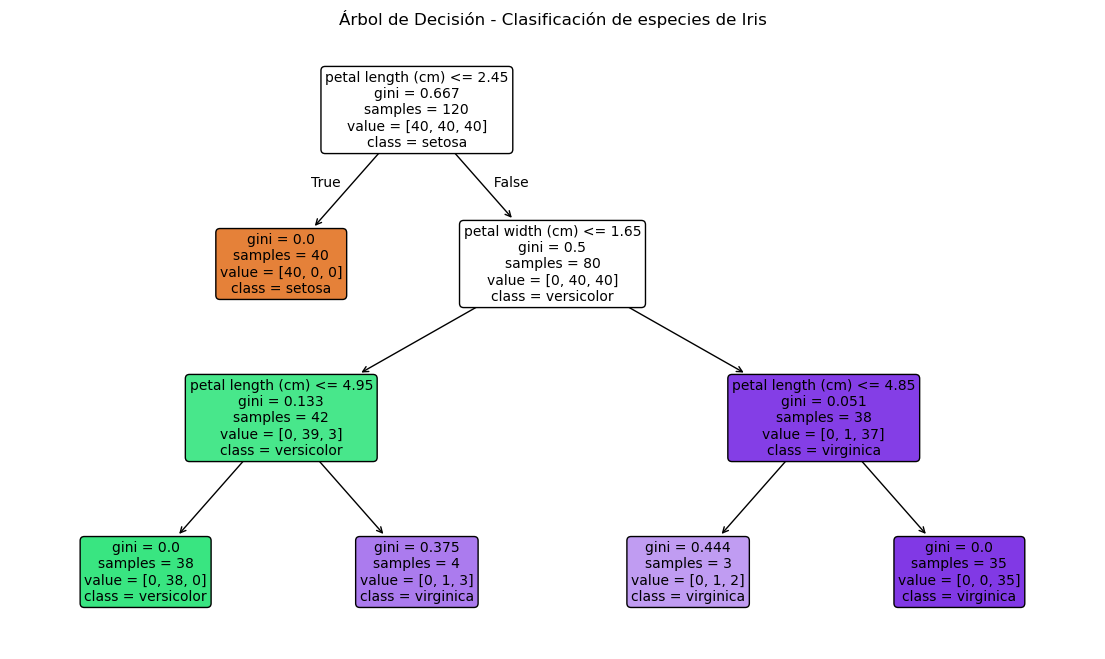

In [7]:
# Visualización del árbol entrenado
plt.figure(figsize=(14, 8))
plot_tree(
    modelo,
    feature_names=iris.feature_names,
    class_names=modelo.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión - Clasificación de especies de Iris")
plt.show()


### 5. Evaluación del algoritmo

Evaluamos el desempeño del modelo sobre el conjunto de prueba usando:
- **Accuracy** (exactitud)
- **Reporte de clasificación** (precisión, recall, f1-score)
- **Matriz de confusión**


In [8]:
y_pred = modelo.predict(X_test)

exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy): {exactitud:.2%}") ##Muliplica x100 y anade con 2 decimales


Exactitud (Accuracy): 96.67%


In [9]:
print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred))

Reporte de clasificación:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



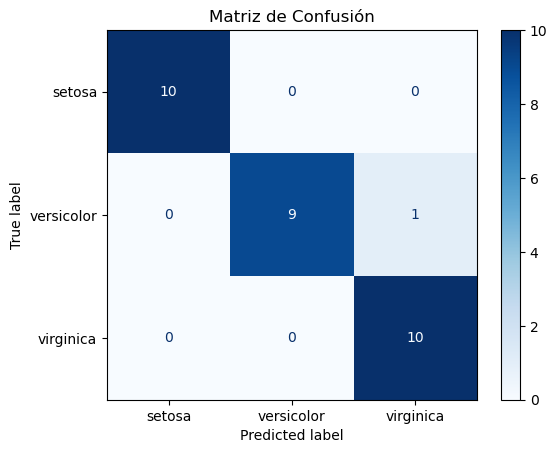

In [10]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()


Importancia de cada variable:

petal length (cm)    0.579077
petal width (cm)     0.420923
sepal length (cm)    0.000000
sepal width (cm)     0.000000
dtype: float64


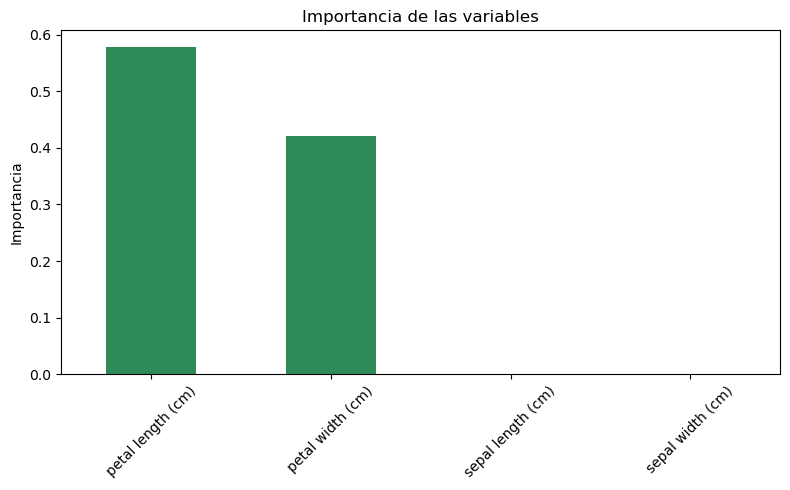

In [11]:
#Importancia de las varaibles
importancias = pd.Series(modelo.feature_importances_, index=iris.feature_names)
importancias = importancias.sort_values(ascending=False)

print("Importancia de cada variable:\n")
print(importancias)

#Grafica de barras
plt.figure(figsize=(8,5))
importancias.plot(kind='bar', color='seagreen')
plt.title("Importancia de las variables")
plt.ylabel("Importancia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Dato nuevo: sepal length, sepal width, petal length, petal width (en cm)
dato_nuevo = pd.DataFrame([[5.8, 2.7, 4.1, 1.0]], columns=iris.feature_names)

prediccion = modelo.predict(dato_nuevo)
probabilidades = modelo.predict_proba(dato_nuevo)

print("Dato nuevo:\n", dato_nuevo)
print("\nClase predicha:", prediccion[0])
print("\nProbabilidades por clase:")
for clase, prob in zip(modelo.classes_, probabilidades[0]):
    print(f"  {clase}: {prob:.2%}")

Dato nuevo:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.8               2.7                4.1               1.0

Clase predicha: versicolor

Probabilidades por clase:
  setosa: 0.00%
  versicolor: 100.00%
  virginica: 0.00%


### Conclusión

El árbol de decisión clasifica las flores usando reglas simples tipo *"si el ancho del pétalo es
menor a X, entonces..."*. Su principal ventaja es que el modelo resultante es **interpretable**:
se puede leer el árbol como un diagrama de flujo de decisiones, lo cual es ideal para explicar el
algoritmo en una presentación.
